In [6]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set scanpy visual & output settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=150, facecolor='white')

# Ensure output figure directory exists using absolute path
fig_dir = os.path.expanduser("~/FYP_Regeneration/results/figures/axolotl/")
os.makedirs(fig_dir, exist_ok=True)
sc.settings.figdir = fig_dir

# Absolute path to raw file
input_path = os.path.expanduser("~/FYP_Regeneration/data/axolotl/processed/GSE106269_Table_S7.csv.gz")
print(f"Loading GSE106269 expression matrix from:\n{input_path}")

df = pd.read_csv(input_path, compression="gzip", index_col=0)

# Identify metadata columns (e.g., celltype, timepoint)
non_numeric_cols = []
for col in df.columns:
    converted = pd.to_numeric(df[col], errors='coerce')
    if converted.isna().sum() > 0.5 * len(df):
        non_numeric_cols.append(col)

print(f"Detected {len(non_numeric_cols)} metadata columns: {non_numeric_cols}")

# Separate metadata and numeric expression matrix
meta_df = df[non_numeric_cols] if non_numeric_cols else pd.DataFrame(index=df.index)
expr_df = df.drop(columns=non_numeric_cols).apply(pd.to_numeric, errors='coerce').fillna(0)

# Construct AnnData object (cells as rows, genes as columns)
if expr_df.shape[0] < expr_df.shape[1]:  # 1209 genes x 15286 cells
    X_mat = expr_df.T.values.astype(np.float32)
    obs_df = pd.DataFrame(index=expr_df.columns)
    var_df = pd.DataFrame(index=expr_df.index)
else:
    X_mat = expr_df.values.astype(np.float32)
    obs_df = meta_df
    var_df = pd.DataFrame(index=expr_df.columns)

adata = sc.AnnData(X=X_mat, obs=obs_df, var=var_df)

# QC Step 1: Filter low-quality cells
sc.pp.filter_cells(adata, min_genes=200)

# QC Step 2: Remove ribosomal protein genes
ribo_genes = adata.var_names.str.startswith(("RPL", "RPS", "rpl", "rps"))
adata = adata[:, ~ribo_genes].copy()

# Save a clean, un-transformed checkpoint object
adata_filtered = adata.copy()

print(f"Cell 1 complete! Clean checkpoint created with {adata_filtered.n_obs} cells x {adata_filtered.n_vars} genes.")

Loading GSE106269 expression matrix from:
/home/ghayyas/FYP_Regeneration/data/axolotl/processed/GSE106269_Table_S7.csv.gz
Detected 2 metadata columns: ['celltype', 'timepoint']
filtered out 8986 cells that have less than 200 genes expressed
Cell 1 complete! Clean checkpoint created with 6300 cells x 1209 genes.


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Highly variable genes identified: 576
computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:08)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


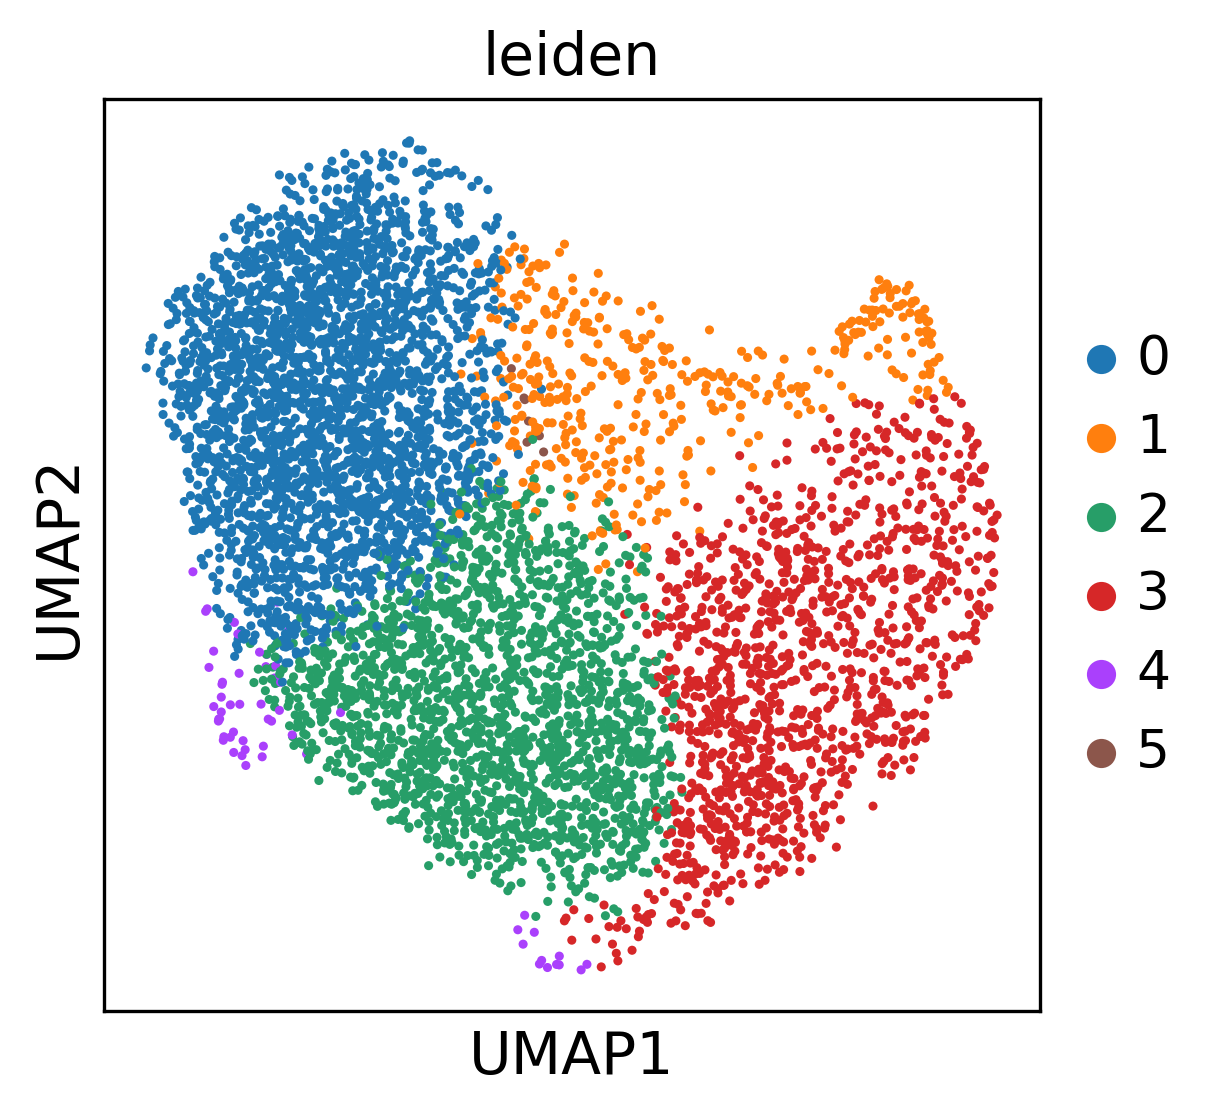

Cell 2 complete! UMAP generated and stored cleanly in adata.


In [7]:
# Cell 2: Normalization, HVGs, PCA, UMAP & Clustering

# Always reset to the clean filtered checkpoint to prevent double-transformation
adata = adata_filtered.copy()

# 1. Normalize total counts per cell to 10,000 and log-transform ONCE
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 2. Identify highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.2)
print(f"Highly variable genes identified: {sum(adata.var.highly_variable)}")

# 3. Create a scaled copy ONLY for PCA/UMAP (leaves primary adata.X unscaled log1p)
adata_scaled = sc.pp.scale(adata, max_value=10, copy=True)

# 4. Dimensionality reduction & Neighborhood graph on scaled data
sc.tl.pca(adata_scaled, svd_solver='arpack')
sc.pp.neighbors(adata_scaled, n_neighbors=15, n_pcs=30)

# 5. UMAP Embedding & Leiden Clustering on scaled data
sc.tl.umap(adata_scaled)
sc.tl.leiden(adata_scaled, resolution=0.5, flavor="igraph", directed=False)

# Transfer UMAP coordinates and Leiden clusters back to primary unscaled adata
adata.obsm['X_umap'] = adata_scaled.obsm['X_umap']
adata.obs['leiden'] = adata_scaled.obs['leiden']

# 6. Plot and save UMAP
color_vars = ['leiden']
if 'celltype' in adata.obs.columns:
    color_vars.append('celltype')
if 'timepoint' in adata.obs.columns:
    color_vars.append('timepoint')

sc.pl.umap(adata, color=color_vars, save='_axolotl_clusters.png')
print("Cell 2 complete! UMAP generated and stored cleanly in adata.")

Computing marker genes using unscaled log-normalized counts...
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


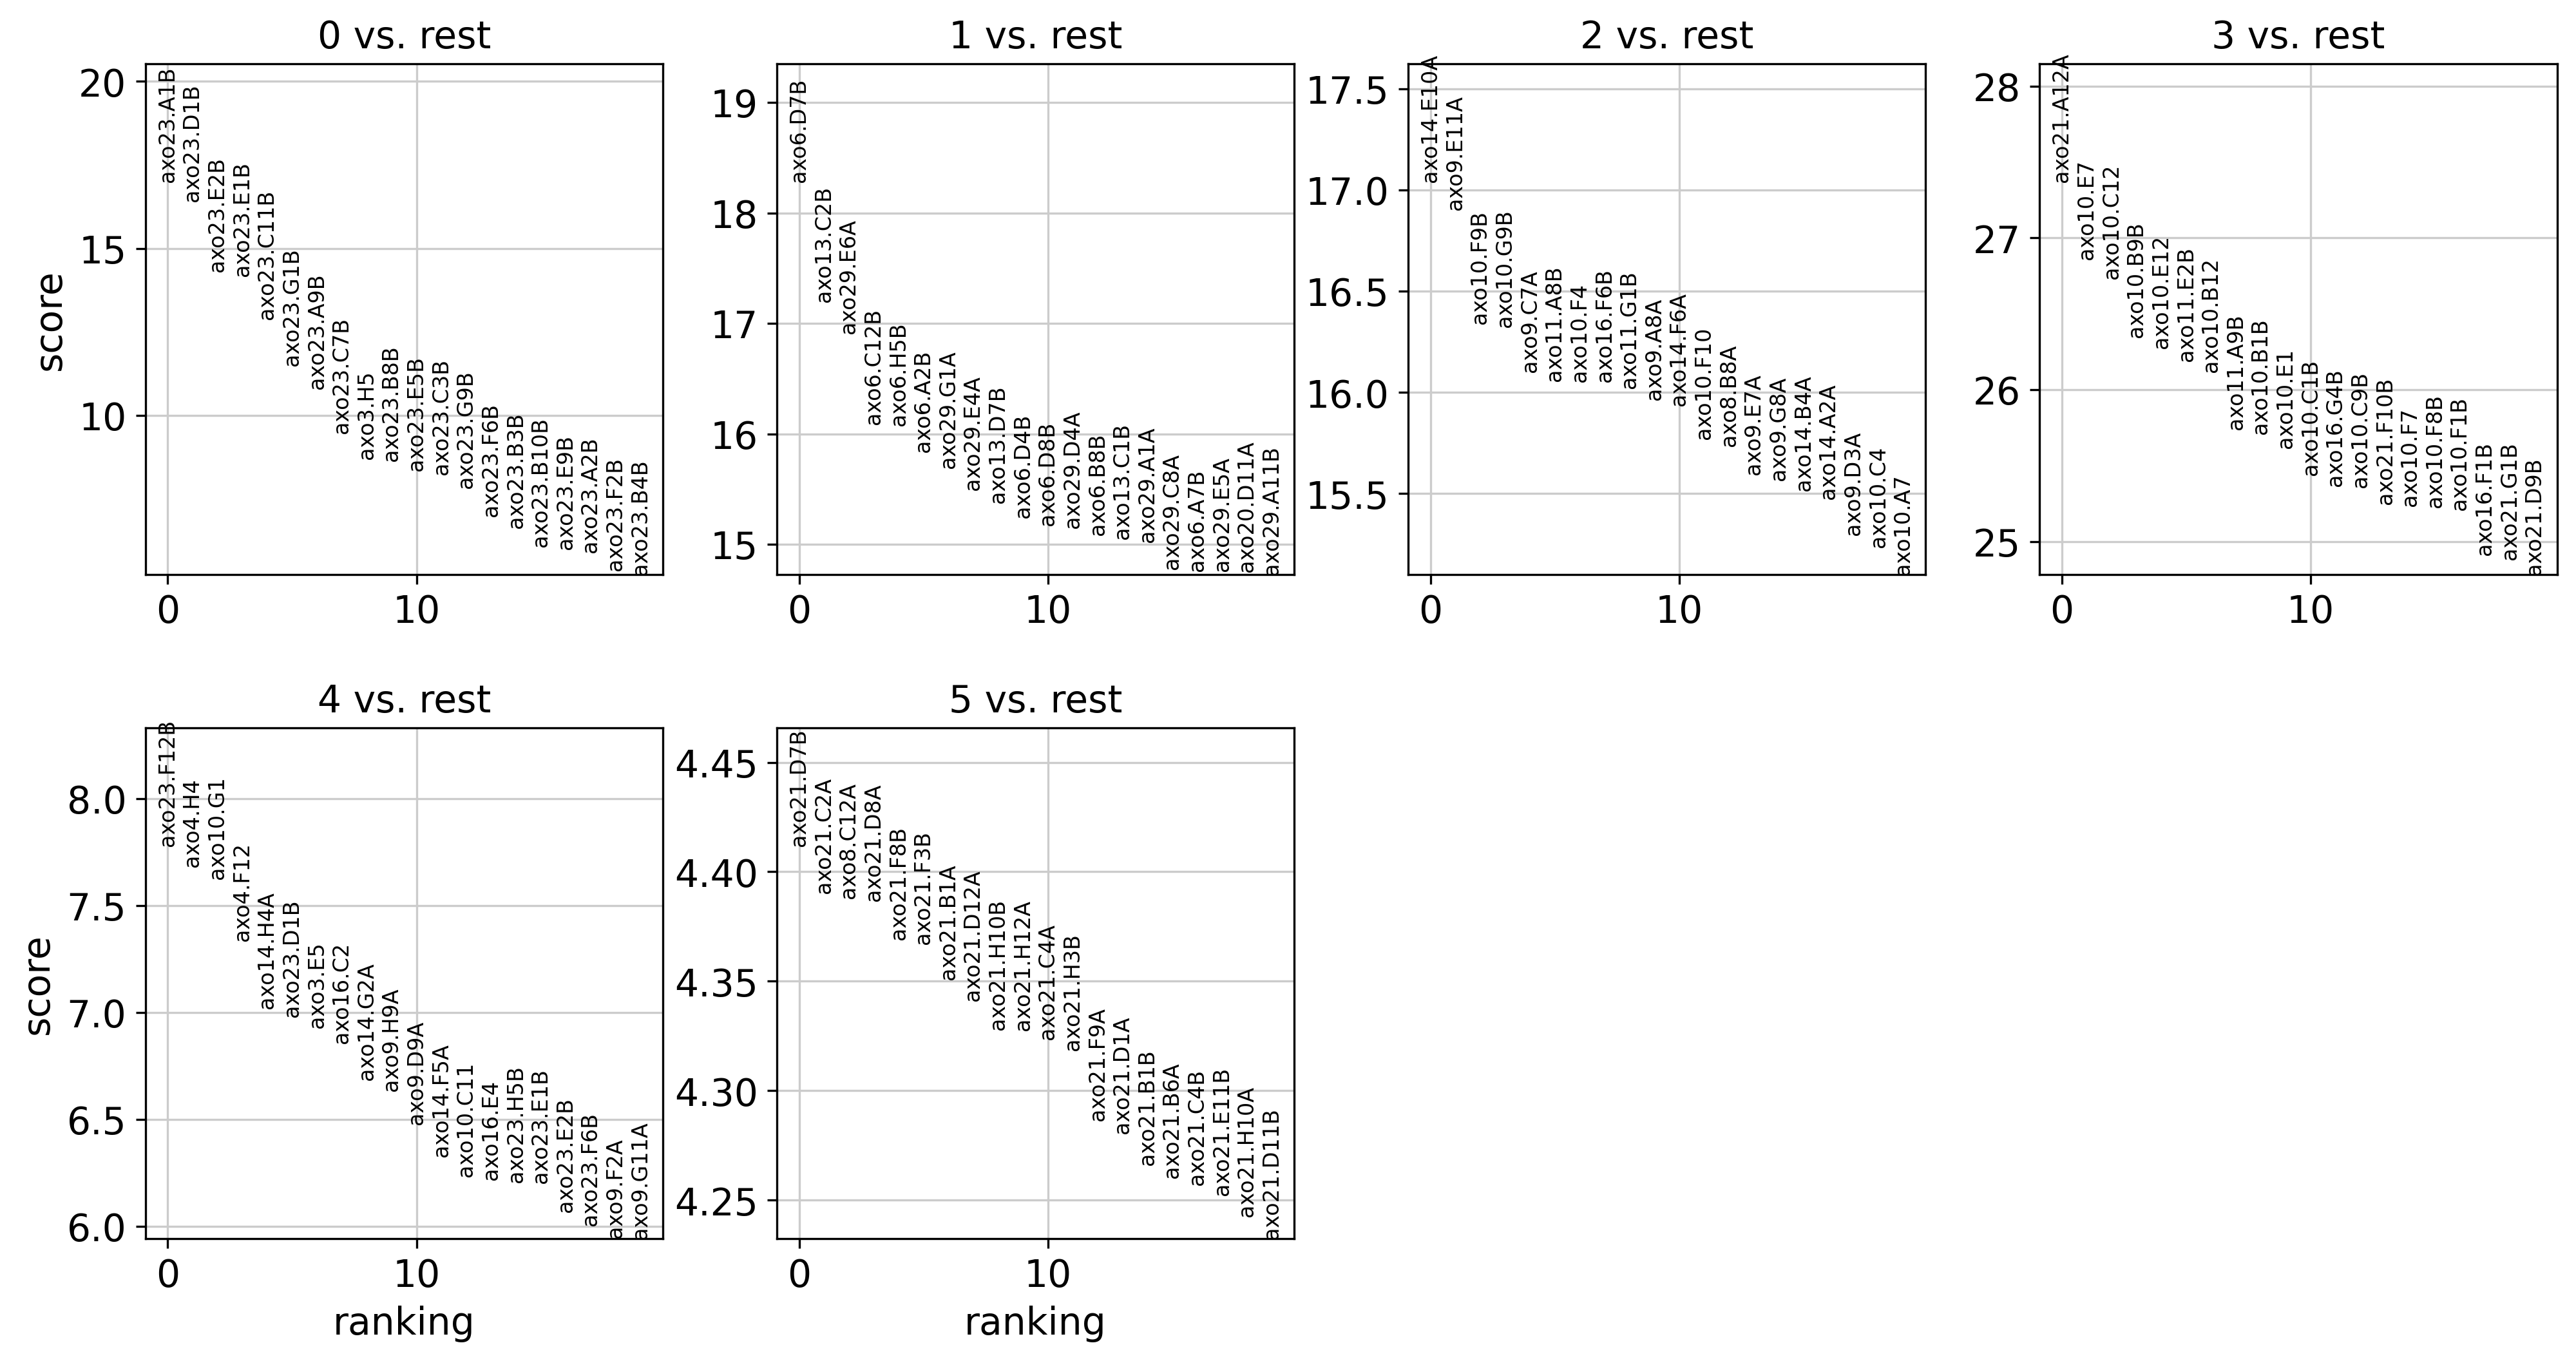

Cell 3 complete!
- All markers saved to: /home/ghayyas/FYP_Regeneration/results/tables/axolotl_de_markers_all.csv
- Significant markers saved to: /home/ghayyas/FYP_Regeneration/results/tables/axolotl_de_markers_sig.csv
- Processed AnnData saved to: /home/ghayyas/FYP_Regeneration/data/axolotl/processed/axolotl_processed.h5ad
- Total significant markers found: 2722


In [8]:
# Cell 3: Marker Gene Extraction & File Export
import os
import pandas as pd
import scanpy as sc

# 1. Compute cluster-specific marker genes directly on unscaled log1p data
print("Computing marker genes using unscaled log-normalized counts...")
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# Save top marker gene plot
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False, save='_axolotl_markers.png')

# 2. Extract marker gene tabular results
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

markers_list = []
for group in groups:
    df_group = pd.DataFrame({
        'cluster': group,
        'gene': result['names'][group],
        'logfoldchanges': result['logfoldchanges'][group],
        'pvals_adj': result['pvals_adj'][group],
        'scores': result['scores'][group]
    })
    markers_list.append(df_group)

markers_df = pd.concat(markers_list, ignore_index=True)

# Filter for significant markers (p_adj < 0.05 and logFC > 0.25)
sig_markers = markers_df[(markers_df['pvals_adj'] < 0.05) & (markers_df['logfoldchanges'] > 0.25)]

# 3. Export CSV tables to results/tables/
tables_dir = os.path.expanduser("~/FYP_Regeneration/results/tables/")
os.makedirs(tables_dir, exist_ok=True)

markers_df.to_csv(os.path.join(tables_dir, "axolotl_de_markers_all.csv"), index=False)
sig_markers.to_csv(os.path.join(tables_dir, "axolotl_de_markers_sig.csv"), index=False)

# 4. Save processed AnnData object to data/axolotl/processed/
output_h5ad = os.path.expanduser("~/FYP_Regeneration/data/axolotl/processed/axolotl_processed.h5ad")
adata.write(output_h5ad, compression="gzip")

print("Cell 3 complete!")
print(f"- All markers saved to: {tables_dir}axolotl_de_markers_all.csv")
print(f"- Significant markers saved to: {tables_dir}axolotl_de_markers_sig.csv")
print(f"- Processed AnnData saved to: {output_h5ad}")
print(f"- Total significant markers found: {len(sig_markers)}")